# Themes

A theme is the complete set of style attributes the charts read when they are built: the palettes, the fonts, the axes furniture, and the per-chart defaults, one value per key of [StyleAttrs](../../../references/typings/#datachart.typings.StyleAttrs). The package ships fourteen predefined themes, each named for its visual trait; the [Theme Gallery](../theme-gallery/) shows their color swatches and signature charts, grouped by use. Themes are applied and built through the global [config](../../../references/config/) instance:

| Task                                       | Method                          | Section                                                   |
| :----------------------------------------- | :------------------------------ | :-------------------------------------------------------- |
| Switch the look of every chart             | `set_theme`, `list_themes`      | [Applying a Theme](#applying-a-theme)                     |
| Switch it for one block only               | `using_theme`                   | [Applying a Theme](#applying-a-theme)                     |
| Read and change single attributes          | `config[...]`, `update_config`, `override` | [What a Theme Controls](#what-a-theme-controls) |
| Make your own theme switchable by name     | `register_theme`                | [Building Your Own Theme](#building-your-own-theme)       |
| Recolour a theme from a colormap           | `derive_theme`                  | [Deriving a Theme from a Colormap](#deriving-a-theme-from-a-colormap) |
| Share a theme as a file and load it back   | `save_theme`, `load_theme`      | [Sharing a Theme](#sharing-a-theme)                       |
| Return to the default theme                | `reset_config`                  | [Applying a Theme](#applying-a-theme)                     |

In [1]:
from datachart.config import config
from datachart.constants import FONT_WEIGHT, THEME


The examples render one figure throughout, a grouped bar chart beside a line chart, so the theme is the only thing that changes between renders. The chart code is left out of this page; see the [chart guides](../../charts/) for it.


In [2]:
import random

from IPython.display import HTML, display

from datachart.charts import BarChart, LineChart
from datachart.utils import Grid

random.seed(7)

REGIONS = ["North", "South", "East"]
QUARTERS = ["Q1", "Q2", "Q3", "Q4"]
REVENUE = [
    [{"label": q, "y": 40 + 15 * i + random.uniform(-8, 12)} for q in QUARTERS]
    for i in range(len(REGIONS))
]
PLANS = ["Free", "Pro", "Team"]
USERS = [
    [{"x": m, "y": 100 + 6 * i * m + random.uniform(-10, 10)} for m in range(1, 13)]
    for i in range(len(PLANS))
]


def demo():
    bars = BarChart(
        data=REVENUE,
        subtitle=REGIONS,
        title="Revenue by quarter",
        ylabel="M€",
        show_legend=True,
    )
    lines = LineChart(
        data=USERS,
        subtitle=PLANS,
        title="Active users",
        xlabel="Month",
        ylabel="Thousands",
        show_legend=True,
    )
    return Grid([[bars, lines]], figsize=(9, 3.2))


SWATCH_CSS = """
<style>
.theme-swatches { display: flex; flex-wrap: wrap; gap: .8em 1.2em; margin: .6em 0 1em; }
.theme-swatches .swatch { display: flex; flex-direction: column; align-items: center; gap: .3em; font-size: .7em; }
.theme-swatches .swatch > span { display: block; width: 2.6em; height: 2.6em; border-radius: .3em; box-shadow: inset 0 0 0 1px rgba(0,0,0,.12); }
.theme-swatches code { background: none; padding: 0; }
</style>
"""


def swatches(colors):
    tiles = "".join(
        f'<div class="swatch"><span style="background:{c}"></span><code>{c}</code></div>'
        for c in colors
    )
    display(HTML(f'{SWATCH_CSS}<div class="theme-swatches">{tiles}</div>'))


## Applying a Theme

`list_themes` returns every name `set_theme` accepts: the predefined themes from [THEME](../../../references/constants/#datachart.constants.THEME) plus any theme registered in this process.


In [3]:
config.list_themes()


['default',
 'greyscale',
 'ink',
 'hatch',
 'minimal',
 'material',
 'sketch',
 'quill',
 'harbor',
 'muted',
 'contrast',
 'mutedhatch',
 'slatehatch',
 'dark']

Applying a theme replaces the whole configuration. Charts read the configuration when they are built, so set the theme before building the charts it should style; the active theme's name is in `config.theme`.


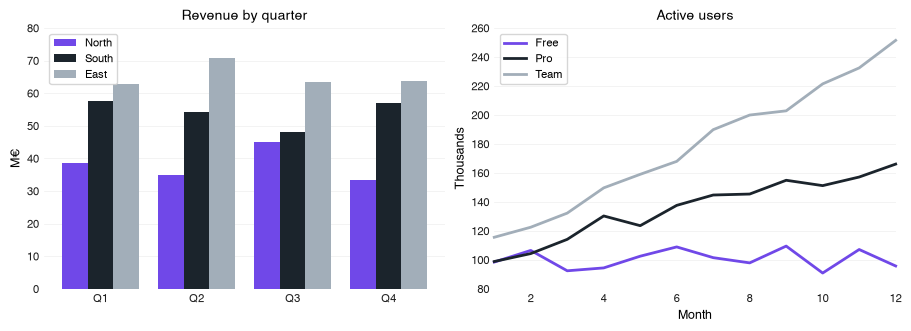

In [4]:
config.set_theme(THEME.MINIMAL)
demo().show()


`using_theme` applies a theme for one `with` block and restores the configuration that entered the block when it ends, also when the block raises. The scopes are plain save-and-restore on the global configuration, so they are neither thread-safe nor async-safe.


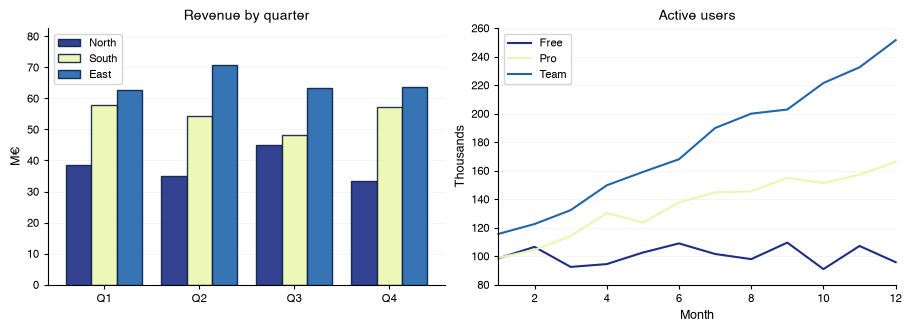

'minimal'

In [5]:
with config.using_theme(THEME.INK):
    demo().show()

config.theme


`reset_config` returns to the default theme, discarding every change made since:


In [6]:
config.reset_config()
config.theme


'default'

Beyond style, a theme carries defaults for chart settings ([ThemeDefaultAttrs](../../../references/typings/#datachart.typings.ThemeDefaultAttrs)): `chart_default_show_grid` supplies the grid when a chart call leaves `show_grid` unset (every predefined theme but [`SKETCH`](../theme-gallery/#sketch) and [`QUILL`](../theme-gallery/#quill) ships a muted `"y"` grid), `chart_default_show_values` does the same for value labels (no predefined theme turns them on), a setting one chart owns takes that chart's name (`chart_default_calendar_heatmap_week_start`, `chart_default_ridgeline_overlap`, `chart_default_network_label_position`), and the `plot_hatch_cycle`, `plot_linestyle_cycle`, and `plot_marker_cycle` attributes tell series apart by pattern where a theme ships them ([`HATCH`](../theme-gallery/#hatch) and [`QUILL`](../theme-gallery/#quill)). A setting given in the chart call always wins over the theme default.


## What a Theme Controls

The attribute names are the keys of the live configuration, grouped by prefix; the [typings reference](../../../references/typings/) documents each one.

| Prefix                                                       | Controls                                                                                                           | Reference |
| :----------------------------------------------------------- | :----------------------------------------------------------------------------------------------------------------- | :-------- |
| `color_*`, `muted_*`                                         | The palettes: `multiple` for series sharing one axes and for subplots, `singular` where one color is needed; the muted color of de-emphasized series | [ColorStyleAttrs](../../../references/typings/#datachart.typings.ColorStyleAttrs) |
| `font_*`                                                     | The font family and its stacks, and the size, color, style, and weight of each text role: general, title, subtitle, axis labels | [FontStyleAttrs](../../../references/typings/#datachart.typings.FontStyleAttrs) |
| `axes_*`, `figure_*`                                         | The spines, the ticks, and the face colors of the figure and the axes                                             | [AxesStyleAttrs](../../../references/typings/#datachart.typings.AxesStyleAttrs) |
| `plot_grid_*`, `plot_legend_*`, `plot_text_*`, `plot_value_*` | The furniture every chart shares: grid lines, legend, annotations, value labels                                   | [GridStyleAttrs](../../../references/typings/#datachart.typings.GridStyleAttrs), [LegendStyleAttrs](../../../references/typings/#datachart.typings.LegendStyleAttrs), [TextStyleAttrs](../../../references/typings/#datachart.typings.TextStyleAttrs), [ValueLabelStyleAttrs](../../../references/typings/#datachart.typings.ValueLabelStyleAttrs) |
| `plot_<chart>_*`                                             | One group per chart type: `plot_line_*`, `plot_bar_*`, `plot_heatmap_*`, and so on                                | The chart's guide, under "Customize" |
| `overlay_*`                                                  | How a [Panel](../../utility/panel/) combines charts: the twin-axis threshold, drawing order, bar mode             | [Panel](../../utility/panel/#panel-configuration) |
| `chart_default_*`, `plot_*_cycle`                            | The chart-setting defaults above: `chart_default_<setting>`, or `chart_default_<chart>_<setting>` for a setting one chart owns | [ThemeDefaultAttrs](../../../references/typings/#datachart.typings.ThemeDefaultAttrs) |

Two themes add groups of their own: [`SKETCH`](../theme-gallery/#sketch) the path wobble and halo of its hand-drawn look ([SketchStyleAttrs](../../../references/typings/#datachart.typings.SketchStyleAttrs)), [`QUILL`](../theme-gallery/#quill) the pen strokes and etched fills of its ink look ([InkStyleAttrs](../../../references/typings/#datachart.typings.InkStyleAttrs)).

Read an attribute by indexing `config` or with `config.get`; the live dictionary is `config.config`, so a prefix lists a whole group:


In [7]:
config["color_general_multiple"], config.get("font_general_family")


(['#3B76B0', '#E8A63E', '#2F9E82', '#C24E2A', '#7CBCE4', '#444444'],
 'sans-serif')

In [8]:
{key: value for key, value in config.config.items() if key.startswith("axes_")}


{'axes_spines_top_visible': False,
 'axes_spines_right_visible': False,
 'axes_spines_bottom_visible': True,
 'axes_spines_left_visible': True,
 'axes_spines_width': 0.8,
 'axes_spines_zorder': 100,
 'axes_ticks_length': 3,
 'axes_ticks_label_size': 8,
 'axes_facecolor': None,
 'axes_spines_color': None,
 'axes_ticks_color': None,
 'axes_xticks_label_rotate': None,
 'axes_yticks_label_rotate': None}

`update_config` changes attributes on top of the active theme; the change persists until the next `set_theme` or `reset_config`, and unknown attribute names are skipped with a warning. `override` does the same for one `with` block, taking a dictionary or keyword arguments. Palette attributes also accept a single color, used for every series that asks for one.


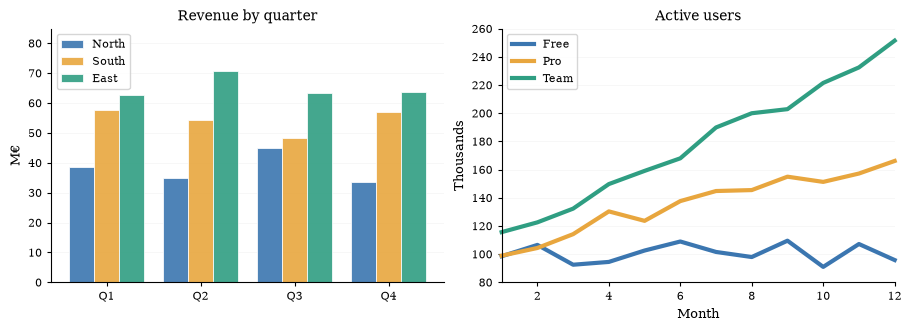

In [9]:
config.update_config({"font_general_family": "serif", "plot_line_width": 3})
demo().show()


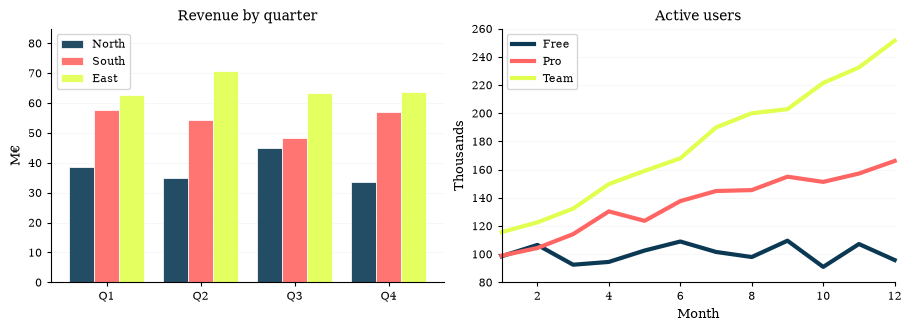

In [10]:
with config.override(color_general_multiple=["#0B3954", "#FF6663", "#E0FF4F"]):
    demo().show()

config.reset_config()


## Building Your Own Theme

A custom theme is a dictionary of the attributes that differ from the default theme. `register_theme` fills the rest from the default theme and rejects unknown names, so a theme can be as short as one palette. To build on another predefined theme instead, spread it first: `{**MINIMAL_THEME, ...}` with the dictionaries of the [themes](../../../references/themes/) module.

The theme built here is a neon noir look: a near-black ground, a cyan, magenta, and amber palette, monospaced type, and the furniture dimmed so the series carry the light. It starts with the palette:


In [11]:
NEON_COLORS = ["#00E5FF", "#FF2D95", "#FFB000", "#7DFF5A", "#B26BFF"]
swatches(NEON_COLORS)


Score the palette before building on it: [`score_palette`](../../../references/themes/#datachart.themes.score_palette) compares every pair of colours as deutan, protan and tritan readers see them and reports the closest pair with a verdict, the same check `register_theme` warns through when a palette fails. Neon colours sit close in lightness, so amber and green come within ΔE 8 for deutan readers and the verdict is `weak`, a palette to pair with a dash or marker cycle; a `fail` would warn when the theme is registered:

In [12]:
from datachart.themes import score_palette

score_palette(NEON_COLORS, face="#0B0F19")

PaletteScore(colors=('#00E5FF', '#FF2D95', '#FFB000', '#7DFF5A', '#B26BFF'), deutan=7.8, protan=16.0, tritan=4.9, normal=21.3, grey_gap=0.6, low_contrast=0, worst_kind='deutan', worst_pair=('#FFB000', '#7DFF5A'), verdict='weak')

The rest of the dictionary sets the ground, the type, and the furniture. `font_general_family` takes `serif` or `sans-serif` to use the theme's font stacks, or any family matplotlib resolves, here the generic `monospace`; a `None` in a color attribute keeps matplotlib's own color, so every color a dark ground needs is set explicitly:


In [13]:
NEON = {
    # ground
    "figure_facecolor": "#0B0F19",
    "axes_facecolor": "#0B0F19",
    # palettes: the series colors, and a two-stop ramp for value scales
    "color_general_multiple": NEON_COLORS,
    "color_general_singular": ["#1B2A4A", "#00E5FF"],
    "muted_color": "#3A4656",
    # type
    "font_general_family": "monospace",
    "font_general_color": "#E6EDF3",
    "font_title_color": "#00E5FF",
    "font_title_weight": FONT_WEIGHT.BOLD,
    "font_subtitle_color": "#9AA5B1",
    "font_xlabel_color": "#9AA5B1",
    "font_ylabel_color": "#9AA5B1",
    # furniture: open top and right, dim spines, dotted grid, dark legend
    "axes_spines_top_visible": False,
    "axes_spines_right_visible": False,
    "axes_spines_color": "#2A3548",
    "axes_ticks_color": "#9AA5B1",
    "plot_grid_color": "#222D40",
    "plot_grid_alpha": 1.0,
    "plot_grid_linestyle": ":",
    "plot_legend_face_color": "#111827",
    "plot_legend_edge_color": "#2A3548",
    "plot_legend_label_color": "#E6EDF3",
    "plot_value_color": "#E6EDF3",
    # marks: heavier strokes, no bar outlines
    "plot_line_width": 2.2,
    "plot_bar_edge_width": 0,
}


Try it before registering: `override` renders the figure under the dictionary and leaves the configuration untouched.


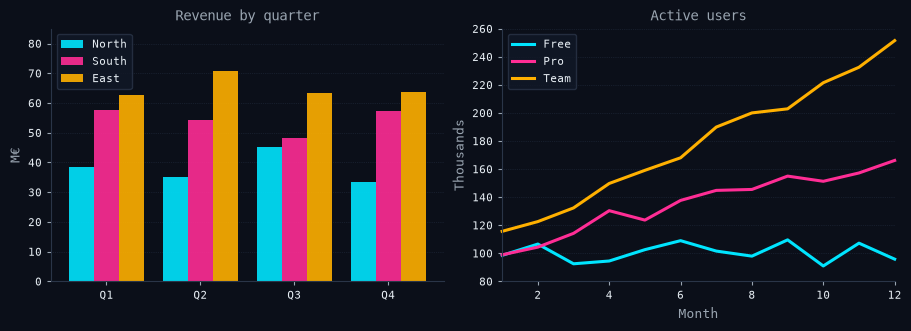

'default'

In [14]:
with config.override(NEON):
    demo().show()

config.theme


Register the dictionary under a name and it behaves like a predefined theme: it appears in `list_themes`, `set_theme` and `using_theme` apply it, and `update_config` tweaks on top of it, here lifting the axes off the ground with a lighter face:


In [15]:
config.register_theme("neon", NEON)
config.set_theme("neon")
config.list_themes()


['default',
 'greyscale',
 'ink',
 'hatch',
 'minimal',
 'material',
 'sketch',
 'quill',
 'harbor',
 'muted',
 'contrast',
 'mutedhatch',
 'slatehatch',
 'dark',
 'neon']

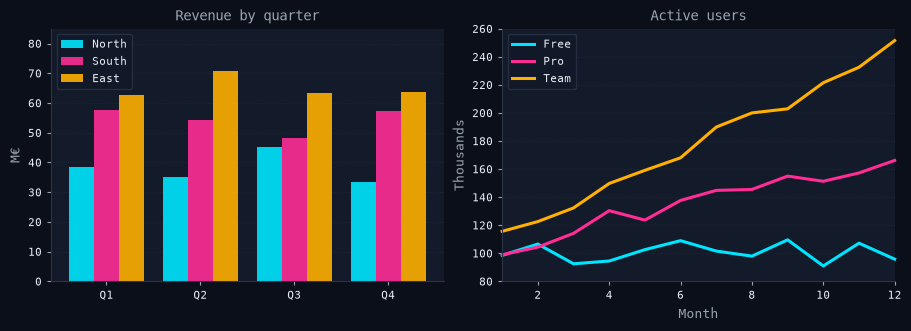

In [16]:
config.update_config({"axes_facecolor": "#131A2A"})
demo().show()


<div class="admonition note">
    <p class="admonition-title">Adding the theme to the <code>datachart</code> package</p>
    <p style="margin-top: .6rem; margin-bottom: .6rem">
        If you think the theme would be useful to others, open a pull request that adds it to the <code>datachart.themes</code> module.
    </p>
</div>


## Deriving a Theme from a Colormap

Every predefined theme is a *lead* colormap plus the palettes sampled from it, and most of the colormaps in [COLORS](../../../references/constants/#datachart.constants.COLORS) back no theme. `derive_theme` takes a base theme and a lead and rebuilds only the lead-dependent attributes, so a theme with a different hue is one call rather than a copied dictionary. The base is a [THEME](../../../references/constants/#datachart.constants.THEME) constant, a registered name, or a theme dictionary; the lead is a `COLORS` constant, any pypalettes name, or a list of colors. Fonts, spines, hatches, and sketch or ink rendering stay as the base sets them.

A **sequential** lead (its lightness runs one way, like `Greens` or `Viridis`) becomes the value scale, `color_general_singular` and `plot_heatmap_cmap`; the series palette is six of its colors in lightness steps, interleaved dark and light so neighbouring series stay apart, the parallel coords ramp is four of them, and the dumbbell pair its lightest and darkest sample. The result is a plain dictionary, so `override` tries it out:

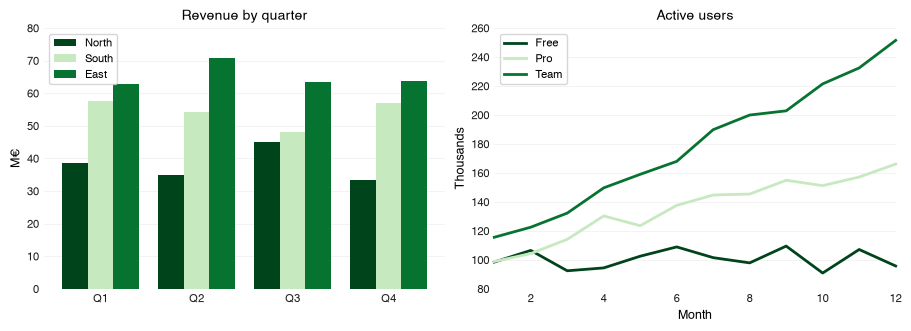

In [17]:
from datachart.constants import COLORS
from datachart.themes import derive_theme

forest = derive_theme(THEME.MINIMAL, lead=COLORS.Greens)
swatches(forest["color_general_multiple"])
with config.override(forest):
    demo().show()

A **categorical** lead (`Tab10`, `Set2`, `Dark2`, or your own list of swatches) becomes the series palette, its first color the singular one, and the base keeps its value scale, ramp, and dumbbell pair. A diverging map is neither: its lightness turns in the middle, so it reads as categorical and is not a lead.

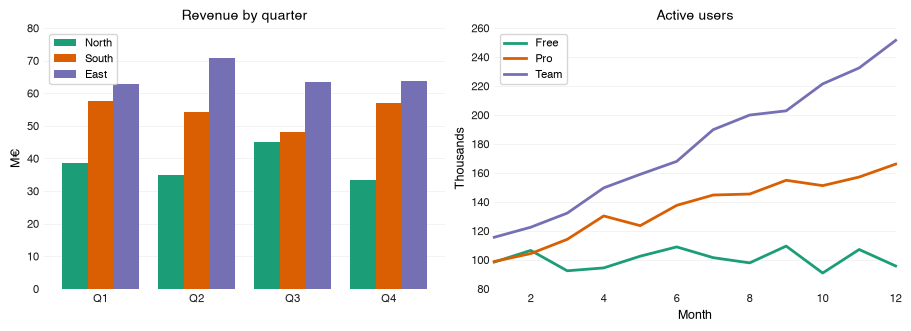

In [18]:
with config.override(derive_theme(THEME.MINIMAL, lead=COLORS.Dark2)):
    demo().show()

Keyword arguments set any other attribute on the result, an unknown name raises, and `register_theme` makes the variant switchable by name like any theme; a dark base keeps the samples off its page:

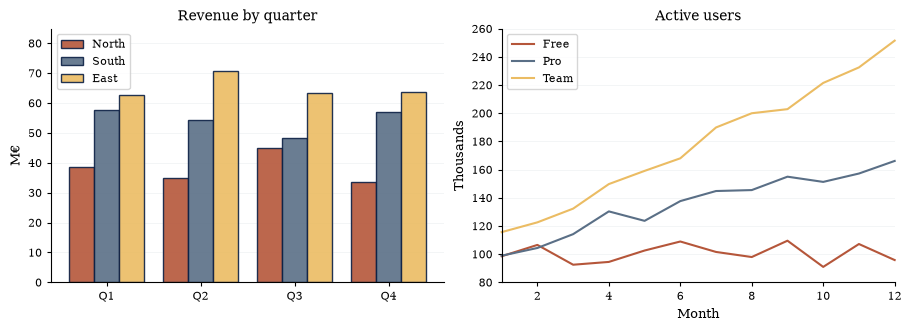

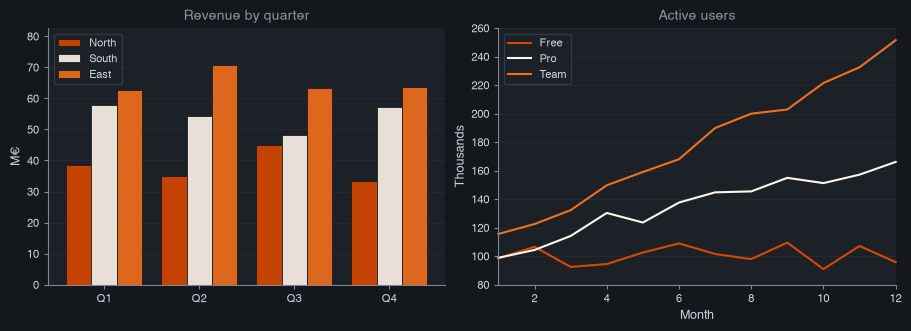

In [19]:
ember = derive_theme(THEME.INK, lead=COLORS.Rust, font_general_family="serif")
config.register_theme("ember", ember)
with config.using_theme("ember"):
    demo().show()

with config.override(derive_theme(THEME.DARK, lead=COLORS.Oranges)):
    demo().show()

Traits are the third ingredient. A [`TRAIT`](../../../references/constants/#datachart.constants.TRAIT) is a named set of mark keys and nothing else: `FLAT` (no edges, opaque bars, 2 pt lines), `EDGED` (black bar and histogram edges), `HATCHED` (edged plus one hatch per bar series), `OUTLINED` (black outlines on every other mark) and `PATTERNED` (dash and marker cycles). `derive_theme` applies them in the order given, after the lead and before the keyword overrides, so a later trait wins a shared key. The harbor, muted, contrast, hatch, muted-hatch and slate-hatch themes are built exactly this way from the default theme, a named `COLORS` lead and one or two traits; here is the muted-hatch recipe with its value scale, the grid and line width left to the default theme, and a print variant of the minimal look:

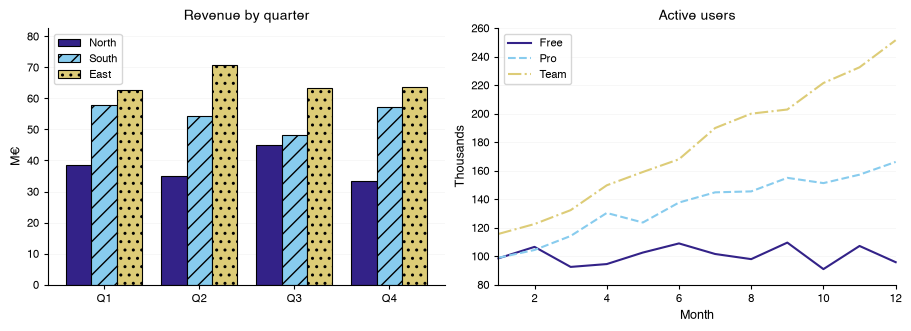

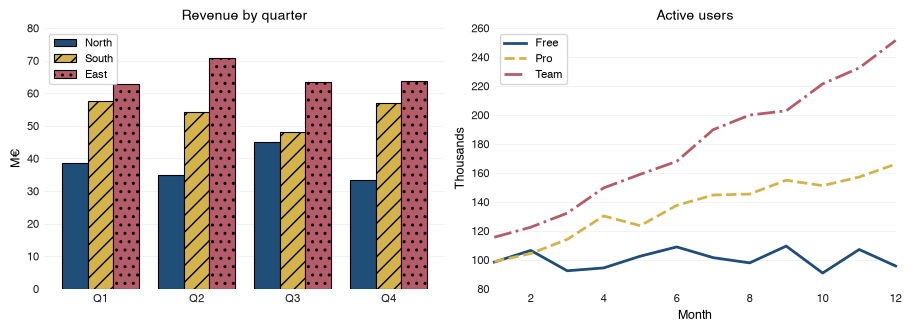

In [20]:
from datachart.constants import TRAIT

mutedhatch = derive_theme(
    THEME.DEFAULT,
    lead=COLORS.TolMuted,
    traits=[TRAIT.PATTERNED, TRAIT.HATCHED],
    plot_heatmap_cmap=COLORS.BuPu,
)
with config.override(mutedhatch):
    demo().show()

with config.override(derive_theme(THEME.MINIMAL, lead=COLORS.Contrast, traits=[TRAIT.PATTERNED, TRAIT.HATCHED])):
    demo().show()

## Sharing a Theme

`save_theme` writes a theme file: a JSON document carrying a name, a format version, and only the attributes that differ from the default theme, so the file stays short and reviewable. A registered theme is saved by name; with no name the live configuration is saved, so a look assembled with `update_config` leaves the process too.


In [21]:
import tempfile
from pathlib import Path

folder = Path(tempfile.mkdtemp())
config.save_theme(folder / "neon.json", name="neon")
print((folder / "neon.json").read_text())


{
    "name": "neon",
    "format_version": 1,
    "attributes": {
        "color_general_singular": [
            "#1B2A4A",
            "#00E5FF"
        ],
        "color_general_multiple": [
            "#00E5FF",
            "#FF2D95",
            "#FFB000",
            "#7DFF5A",
            "#B26BFF"
        ],
        "muted_color": "#3A4656",
        "font_general_family": "monospace",
        "font_general_color": "#E6EDF3",
        "font_title_color": "#00E5FF",
        "font_title_weight": "bold",
        "font_subtitle_color": "#9AA5B1",
        "font_xlabel_color": "#9AA5B1",
        "font_ylabel_color": "#9AA5B1",
        "figure_facecolor": "#0B0F19",
        "axes_facecolor": "#0B0F19",
        "axes_spines_color": "#2A3548",
        "axes_ticks_color": "#9AA5B1",
        "plot_legend_label_color": "#E6EDF3",
        "plot_legend_edge_color": "#2A3548",
        "plot_legend_face_color": "#111827",
        "plot_grid_alpha": 1.0,
        "plot_grid_color": "#222D40",
  

`load_theme` registers the theme in a file and returns the name it registered under: the `name` argument, else the name in the file, else the file's stem. Loading only registers; apply the theme with `set_theme` or `using_theme`. The file is validated the way `register_theme` validates a dictionary, so a hand-edited file cannot register a broken theme.


In [22]:
name = config.load_theme(folder / "neon.json", name="neon-shared")
config.set_theme(name)
config.theme


'neon-shared'

A companion package ships its themes the same way: it registers or loads them on import, and its users apply them with `config.set_theme("<name>")`.

Finally, reset the configuration back to the default theme:


In [23]:
config.reset_config()
